# Units TopK SAE retraining and force-specific confirmation

This is the final guarded units experiment. It applies the same fixed TopK `k=128,256,512` sweep and metric-only selection used for mathematics, then performs final-token causal validation. The primary confirmation compares force-sourced feature swaps against matched mass-sourced swaps into the same unseen energy targets.

Only the predeclared Top-10 panel is confirmatory. Other panel sizes, layers and controls are secondary diagnostics and must not replace the primary result after outcomes are viewed.

## 1. Mount Drive and fetch the current repository

In [1]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

import os
import subprocess

repo_url = 'https://github.com/evey-dev/test_run.git'
repo_dir = '/content/test_run'

def run_cmd(command):
    print('$', ' '.join(map(str, command)))
    environment = os.environ.copy()
    environment['PYTHONUNBUFFERED'] = '1'
    process = subprocess.Popen(
        command,
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        text=True,
        bufsize=1,
        env=environment,
    )
    if process.stdout is None:
        raise RuntimeError('Could not capture child-process output')
    for line in process.stdout:
        print(line, end='')
    return_code = process.wait()
    if return_code:
        raise subprocess.CalledProcessError(return_code, command)

github_ok = False
try:
    checkout = repo_dir
    if os.path.isdir(os.path.join(checkout, '.git')):
        run_cmd(['git', '-C', checkout, 'pull', '--ff-only'])
    else:
        if os.path.exists(checkout) and os.listdir(checkout):
            checkout = '/content/test_run_github'
        if os.path.isdir(os.path.join(checkout, '.git')):
            run_cmd(['git', '-C', checkout, 'pull', '--ff-only'])
        elif os.path.exists(checkout) and os.listdir(checkout):
            raise RuntimeError(f'{checkout} exists but is not a git repository')
        else:
            run_cmd(['git', 'clone', '--depth', '1', repo_url, checkout])
    os.chdir(checkout)
    github_ok = True
    print('Using GitHub checkout:', os.getcwd())
except Exception as exc:
    print('GitHub checkout failed; using Drive project.zip backup.')
    print(repr(exc))

if not github_ok:
    zip_path = '/content/drive/MyDrive/mphil-project/project.zip'
    if not os.path.exists(zip_path):
        raise FileNotFoundError(f'Could not find {zip_path}')
    run_cmd(['unzip', '-q', '-o', zip_path, '-d', '/content/'])
    for candidate in ['/content/test_run', '/content/mphil_project/test_run', '/content']:
        if os.path.isdir(os.path.join(candidate, 'src')) and os.path.isdir(os.path.join(candidate, 'configs')):
            os.chdir(candidate)
            break
    else:
        raise FileNotFoundError('Could not locate the extracted repository root')

print('Current working directory:', os.getcwd())

Mounted at /content/drive
$ git clone --depth 1 https://github.com/evey-dev/test_run.git /content/test_run
Cloning into '/content/test_run'...
Using GitHub checkout: /content/test_run
Current working directory: /content/test_run


## 2. Install dependencies and regenerate deterministic data

In [2]:
!pip install -q --upgrade "transformers>=4.51.0" accelerate matplotlib pandas
!pip install -q -e .
!python data/generate_datasets.py --capitals

from pathlib import Path
required_files = [
    Path('src/units_feature_screen.py'),
    Path('src/plot_topk_units.py'),
    Path('configs/sae_units_topk128_config.yaml'),
    Path('configs/sae_units_topk256_config.yaml'),
    Path('configs/sae_units_topk512_config.yaml'),
]
missing = [str(path) for path in required_files if not path.exists()]
if missing:
    raise FileNotFoundError(
        'The GitHub checkout is missing the units TopK follow-up files. Push first: ' + ', '.join(missing)
    )

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 8.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.5/11.5 MB 147.9 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 158.7 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 160.6 MB/s eta 0:00:00a 0:00:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.3 which is incompatible.
cudf-cu12 26.2.1 requires pandas<2.4.0,>=2.0, but you have pandas 3.0.3 which is incompatible.
dask-cudf-cu12 26.2.1 requires pandas<2.4.0,>=2.0, but you have pandas 3.0.3 which is incompatible.
  Preparing metadata (setup.py) ... done
Generating Datasets...

Flag '--capitals' captured. Building structural se

## 3. Fixed candidates and artifact paths

In [3]:
from pathlib import Path
import json
import shutil
import sys

LAYERS = [4, 8, 12, 16, 20, 24, 28]
CANDIDATES = {
    128: 'configs/sae_units_topk128_config.yaml',
    256: 'configs/sae_units_topk256_config.yaml',
    512: 'configs/sae_units_topk512_config.yaml',
}
DRIVE_ROOT = Path('/content/drive/MyDrive/mphil-project')
DRIVE_CHECKPOINT_ROOT = DRIVE_ROOT / 'mechanistic_data' / 'topk_units_retrain'
DRIVE_OUTPUT = DRIVE_ROOT / 'outputs' / 'topk_units_retrain'
LOCAL_OUTPUT = Path('outputs/topk_units_retrain')
FIGURE_OUTPUT = LOCAL_OUTPUT / 'figures'
for path in (DRIVE_CHECKPOINT_ROOT, DRIVE_OUTPUT, LOCAL_OUTPUT, FIGURE_OUTPUT):
    path.mkdir(parents=True, exist_ok=True)

print('Candidates:', CANDIDATES)
print('Drive checkpoint root:', DRIVE_CHECKPOINT_ROOT)
print('Drive output root:', DRIVE_OUTPUT)

Candidates: {128: 'configs/sae_units_topk128_config.yaml', 256: 'configs/sae_units_topk256_config.yaml', 512: 'configs/sae_units_topk512_config.yaml'}
Drive checkpoint root: /content/drive/MyDrive/mphil-project/mechanistic_data/topk_units_retrain
Drive output root: /content/drive/MyDrive/mphil-project/outputs/topk_units_retrain


## 4. Recapture the units final-token activation corpus

This deliberately matches the original units SAE training support. The experiment changes sparsity and decoder normalisation, not the prompt corpus or activation position.

In [4]:
activation_dir = Path('mechanistic_data_units_topk_retrain')
activation_complete = (activation_dir / 'train_val_indices_per_layer.npy').exists() and all(
    (activation_dir / f'activations_layer{layer}.npy').exists() for layer in LAYERS
)
if activation_complete:
    print('Units TopK activation corpus already exists:', activation_dir)
else:
    run_cmd([
        sys.executable, '-m', 'src.capture_activations',
        '--output-dir', str(activation_dir),
        '--behaviours', 'units',
        '--layers', *map(str, LAYERS),
        '--seed', '787',
    ])

$ /usr/bin/python3 -m src.capture_activations --output-dir mechanistic_data_units_topk_retrain --behaviours units --layers 4 8 12 16 20 24 28 --seed 787
Loading model and tokenizer...
Local model path './models/Qwen3-4B-Instruct' not found. Falling back to Hugging Face Hub: Qwen/Qwen3-4B-Instruct-2507

Fetching 3 files: 100%|██████████| 3/3 [00:15<00:00,  5.18s/it]

Loading weights: 100%|██████████| 398/398 [00:02<00:00, 189.30it/s]
Loading prompts for behaviour: units
Total prompts loaded: 1000
Running forward passes to capture activations...

100%|██████████| 1000/1000 [00:56<00:00, 17.64it/s]
Saving activation tensors to disk...
Saved activations for layer 4: (1000, 2560) to /content/test_run/mechanistic_data_units_topk_retrain/activations_layer4.npy
Saved activations for layer 8: (1000, 2560) to /content/test_run/mechanistic_data_units_topk_retrain/activations_layer8.npy
Saved activations for layer 12: (1000, 2560) to /content/test_run/mechanistic_data_units_topk_retrain/activation

## 5. Train or restore all fixed TopK candidates

In [5]:
for top_k, config in CANDIDATES.items():
    drive_dir = DRIVE_CHECKPOINT_ROOT / f'k{top_k}'
    drive_dir.mkdir(parents=True, exist_ok=True)
    print(f'\n=== Training/restoring units TopK {top_k} ===')
    run_cmd([
        sys.executable, '-m', 'src.train',
        '--config', config,
        '--drive-dir', str(drive_dir),
    ])


=== Training/restoring units TopK 128 ===
$ /usr/bin/python3 -m src.train --config configs/sae_units_topk128_config.yaml --drive-dir /content/drive/MyDrive/mphil-project/mechanistic_data/topk_units_retrain/k128
Using CUDA device: NVIDIA A100-SXM4-80GB
[resume] Layer 4 already complete in /content/drive/MyDrive/mphil-project/mechanistic_data/topk_units_retrain/k128; skipping training.
[resume] Layer 8 already complete in /content/drive/MyDrive/mphil-project/mechanistic_data/topk_units_retrain/k128; skipping training.
[resume] Layer 12 already complete in /content/drive/MyDrive/mphil-project/mechanistic_data/topk_units_retrain/k128; skipping training.
[resume] Layer 16 already complete in /content/drive/MyDrive/mphil-project/mechanistic_data/topk_units_retrain/k128; skipping training.
[resume] Layer 20 already complete in /content/drive/MyDrive/mphil-project/mechanistic_data/topk_units_retrain/k128; skipping training.
[resume] Layer 24 already complete in /content/drive/MyDrive/mphil-pr

## 6. Select one candidate before intervention

Selection requires mean validation FVE at least 0.90, every layer FVE at least 0.85, and mean dead-feature fraction at most 0.80. The eligible candidate with the smallest mean validation L0 is selected without using any graph or intervention outcome.

In [6]:
diagnostic_csvs = []
for top_k, config in CANDIDATES.items():
    csv_path = LOCAL_OUTPUT / f'units_topk{top_k}_diagnostics.csv'
    json_path = LOCAL_OUTPUT / f'units_topk{top_k}_diagnostics.json'
    run_cmd([
        sys.executable, '-m', 'src.sae_diagnostics',
        '--config', config,
        '--label', f'units_topk{top_k}',
        '--output-json', str(json_path),
        '--output-csv', str(csv_path),
        '--device', 'auto',
    ])
    diagnostic_csvs.append(csv_path)

selection_path = LOCAL_OUTPUT / 'units_topk_selection.json'
run_cmd([
    sys.executable, '-m', 'src.select_sae_candidate',
    '--configs', *CANDIDATES.values(),
    '--diagnostics', *map(str, diagnostic_csvs),
    '--minimum-mean-fve', '0.90',
    '--minimum-layer-fve', '0.85',
    '--maximum-mean-dead-fraction', '0.80',
    '--output', str(selection_path),
])
selection = json.loads(selection_path.read_text())
if selection.get('selected') is None:
    for source in LOCAL_OUTPUT.glob('units_topk*_diagnostics.*'):
        shutil.copy2(source, DRIVE_OUTPUT / source.name)
    shutil.copy2(selection_path, DRIVE_OUTPUT / selection_path.name)
    raise RuntimeError('No units TopK candidate passed the predeclared thresholds; stop before graph construction.')
SELECTED_K = int(selection['selected']['top_k'])
SELECTED_CONFIG = selection['selected']['config']
print('Selected units TopK candidate:', SELECTED_K, SELECTED_CONFIG)

import pandas as pd
display(pd.DataFrame([
    {
        'k': row['top_k'],
        'mean validation FVE': row['mean_validation_fve'],
        'minimum layer FVE': row['minimum_layer_validation_fve'],
        'mean validation L0': row['mean_validation_l0'],
        'dead-feature fraction': row['mean_dead_feature_fraction'],
        'selected': row['config'] == selection['selected']['config'],
    }
    for row in selection['candidates']
]).round(4))

$ /usr/bin/python3 -m src.sae_diagnostics --config configs/sae_units_topk128_config.yaml --label units_topk128 --output-json outputs/topk_units_retrain/units_topk128_diagnostics.json --output-csv outputs/topk_units_retrain/units_topk128_diagnostics.csv --device auto
Evaluating units_topk128 SAE at layer 4 on cuda...
Evaluating units_topk128 SAE at layer 8 on cuda...
Evaluating units_topk128 SAE at layer 12 on cuda...
Evaluating units_topk128 SAE at layer 16 on cuda...
Evaluating units_topk128 SAE at layer 20 on cuda...
Evaluating units_topk128 SAE at layer 24 on cuda...
Evaluating units_topk128 SAE at layer 28 on cuda...

SAE diagnostic summary (validation split)
domain      layer      FVE   rel_L2   mean_L0   dead_all
units_topk128     4    0.982    0.037      100.3      0.845
units_topk128     8    0.980    0.074       94.4      0.865
units_topk128    12    0.943    0.121      106.8      0.825
units_topk128    16    0.919    0.169      106.8      0.781
units_topk128    20    0.898   

,k,mean validation FVE,minimum layer FVE,mean validation L0,dead-feature fraction,selected
0,128,0.9358,0.8891,99.7686,0.7989,True
1,256,0.9301,0.8776,132.7079,0.6654,False
2,512,0.9267,0.8715,165.5200,0.5386,False


## 7. Restore optional ReLU references and build exactly one selected graph

In [7]:
for name in ('final_sae_diagnostics_units.csv', 'units_final_heldout_last.json'):
    local = Path('outputs') / name
    drive_source = DRIVE_ROOT / 'outputs' / name
    if not local.exists() and drive_source.exists():
        local.parent.mkdir(parents=True, exist_ok=True)
        shutil.copy2(drive_source, local)
        print('Restored reference:', name)

GRAPH_STEM = f'units_topk{SELECTED_K}_force_graph'
graph_paths = {suffix: LOCAL_OUTPUT / f'{GRAPH_STEM}.{suffix}' for suffix in ('json', 'html', 'md')}
drive_graph_paths = {suffix: DRIVE_OUTPUT / f'{GRAPH_STEM}.{suffix}' for suffix in graph_paths}
if all(path.exists() for path in drive_graph_paths.values()):
    for suffix in graph_paths:
        shutil.copy2(drive_graph_paths[suffix], graph_paths[suffix])
    print('Restored selected units graph from Drive:', GRAPH_STEM)
else:
    run_cmd([
        sys.executable, '-m', 'src.attribution_graph',
        '--prompt', 'Fact: The official SI unit for the force of a moving engine thrust is named "',
        '--target', 'newtons',
        '--contrast-target', 'joules',
        '--layers', *map(str, LAYERS),
        '--sae-config', SELECTED_CONFIG,
        '--top-k-nodes', '20',
        '--top-k-edges', '30',
        '--output-json', str(graph_paths['json']),
        '--output-html', str(graph_paths['html']),
        '--output-mermaid', str(graph_paths['md']),
    ])
    for suffix in graph_paths:
        shutil.copy2(graph_paths[suffix], drive_graph_paths[suffix])

Restored reference: final_sae_diagnostics_units.csv
Restored selected units graph from Drive: units_topk128_force_graph


## 8. Final-token graph-held-out benchmark on corpus validation contexts

The fresh units-only split supplies 17 distinct force contexts after filtering. This benchmark fixes the requested count at 16 and leaves one unused reserve context.

In [8]:
heldout_path = LOCAL_OUTPUT / f'units_topk{SELECTED_K}_heldout_last.json'
run_cmd([
    sys.executable, '-m', 'src.heldout_validation',
    '--units-sae-config', SELECTED_CONFIG,
    '--units-graph', str(graph_paths['json']),
    '--unit-cases', '16',
    '--skip-math',
    '--positions', 'last',
    '--output', str(heldout_path),
])
heldout = json.loads(heldout_path.read_text())
display(pd.DataFrame(heldout['units']['summary']['conditions']).T.round(4))

relu_heldout_path = Path('outputs/units_final_heldout_last.json')
if relu_heldout_path.exists():
    relu_heldout = json.loads(relu_heldout_path.read_text())
    comparison = pd.DataFrame({
        'Original ReLU': {
            name: values['mean_gap_delta']
            for name, values in relu_heldout['units']['summary']['conditions'].items()
        },
        f'TopK {SELECTED_K}': {
            name: values['mean_gap_delta']
            for name, values in heldout['units']['summary']['conditions'].items()
        },
    })
    display(comparison.round(4))

$ /usr/bin/python3 -m src.heldout_validation --units-sae-config configs/sae_units_topk128_config.yaml --units-graph outputs/topk_units_retrain/units_topk128_force_graph.json --unit-cases 16 --skip-math --positions last --output outputs/topk_units_retrain/units_topk128_heldout_last.json
Loading language model once for both benchmarks...
Local model path './models/Qwen3-4B-Instruct' not found. Falling back to Hugging Face Hub: Qwen/Qwen3-4B-Instruct-2507

Loading weights: 100%|██████████| 398/398 [00:02<00:00, 189.86it/s]
Loaded 73 positive units graph features
[units 01/16] bullet impact
[units 02/16] bow string tension
[units 03/16] magnetic repulsion
[units 04/16] spring stretch
[units 05/16] wind gust
[units 06/16] elastic band recoil
[units 07/16] gravity pull
[units 08/16] earthquake tremor
[units 09/16] friction drag
[units 10/16] rocket engine
[units 11/16] water jet
[units 12/16] crane lift
[units 13/16] tug of war
[units 14/16] engine thrust
[units 15/16] hydraulic press
[units

,mean_gap_delta,median_gap_delta,bootstrap_95_ci_mean,fraction_in_predicted_direction,top_prediction_transfer_fraction
full_latent_swap,1.351562,1.03125,"[0.78125, 2.0]",1.0,0.0
raw_mlp_swap,1.617188,1.4375,"[1.1875, 2.09375]",1.0,0.0
sparse_feature_swap,0.585938,0.40625,"[0.3515625, 0.8828125]",1.0,0.0


,Original ReLU,TopK 128
full_latent_swap,1.5000,1.3516
raw_mlp_swap,1.6250,1.6172
sparse_feature_swap,0.2292,0.5859


## 9. Fresh-context discovery and confirmation screen

All force, mass and energy prompts in this screen are exact-string absent from the SAE corpus. A baseline-only pilot of the original wording produced only fourteen qualified systems, before any feature intervention was observed. The revised pool therefore uses sixty-four unseen physical systems and clearer matched prompts that place the measured quantity immediately before the requested unit. Discovery remains fixed at eight systems and confirmation at sixteen different systems, with one prompt per system. Eligibility requires the clean energy target and force source to predict their expected unit prefixes. Mass-control correctness is reported and preferred when choosing among prompt variants, but it does not gate eligibility because mass is a negative-control source rather than the causal target. The output is checkpointed directly to Drive after every feature and panel; rerun this cell after interruption to resume.

In [9]:
drive_screen_path = DRIVE_OUTPUT / f'units_topk{SELECTED_K}_feature_screen.json'
run_cmd([
    sys.executable, '-m', 'src.units_feature_screen',
    '--sae-config', SELECTED_CONFIG,
    '--graph', str(graph_paths['json']),
    '--positions', 'last',
    '--discovery-cases', '8',
    '--confirmation-cases', '16',
    '--seed', '2787',
    '--panel-sizes', '1', '3', '5', '10', '20',
    '--primary-panel-size', '10',
    '--random-panels', '5',
    '--output', str(drive_screen_path),
])
local_screen_path = LOCAL_OUTPUT / drive_screen_path.name
shutil.copy2(drive_screen_path, local_screen_path)
screen = json.loads(local_screen_path.read_text())
primary = screen['confirmation']['primary_result']
print('Status:', screen['status'])
print('Candidate features:', screen['candidate_feature_count'])
print('Primary panel:', primary['panel'])
print('Predeclared success rule met:', primary['supports_force_selectivity_under_predeclared_rule'])
display(pd.Series(primary['summary']).to_frame('value'))
display(pd.DataFrame([
    {
        'panel': panel['name'],
        'kind': panel['kind'],
        'features': panel['feature_count'],
        'force delta': panel['summary']['mean_force_source_delta'],
        'mass delta': panel['summary']['mean_mass_source_delta'],
        'force minus mass': panel['summary']['mean_force_minus_mass_difference'],
        'paired 95% CI': panel['summary']['bootstrap_95_ci_mean_force_minus_mass_difference'],
    }
    for panel in screen['confirmation']['panels']
]))

$ /usr/bin/python3 -m src.units_feature_screen --sae-config configs/sae_units_topk128_config.yaml --graph outputs/topk_units_retrain/units_topk128_force_graph.json --positions last --discovery-cases 8 --confirmation-cases 16 --seed 2787 --panel-sizes 1 3 5 10 20 --primary-panel-size 10 --random-panels 5 --output /content/drive/MyDrive/mphil-project/outputs/topk_units_retrain/units_topk128_feature_screen.json
Replacing a pre-intervention checkpoint from an earlier screen protocol: /content/drive/MyDrive/mphil-project/outputs/topk_units_retrain/units_topk128_feature_screen.json
Loading model and selected units TopK SAEs...
Local model path './models/Qwen3-4B-Instruct' not found. Falling back to Hugging Face Hub: Qwen/Qwen3-4B-Instruct-2507

Loading weights: 100%|██████████| 398/398 [00:02<00:00, 189.32it/s]
[baseline 01/256] telescope positioning motor under steady operating conditions
[baseline 02/256] retaining-wall anchor during a controlled load test
[baseline 03/256] robotic gripper

,value
eligible_cases,16
mean_force_source_delta,1.234375
bootstrap_95_ci_mean_force_source_delta,"[1.1484375, 1.33203125]"
mean_mass_source_delta,-0.089844
bootstrap_95_ci_mean_mass_source_delta,"[-0.12890625, -0.05078125]"
mean_force_minus_mass_difference,1.324219
bootstrap_95_ci_mean_force_minus_mass_difference,"[1.22265625, 1.4296875]"
fraction_force_delta_positive,1.0
fraction_force_more_positive_than_mass,1.0
force_top_prediction_transfer_fraction,0.0


,panel,kind,features,force delta,mass delta,force minus mass,paired 95% CI
0,top_1,discovery_ranked_prefix,1,0.277344,-0.074219,0.351562,"[0.31640625, 0.38671875]"
1,top_3,discovery_ranked_prefix,3,0.738281,-0.074219,0.812500,"[0.75, 0.875]"
2,top_5,discovery_ranked_prefix,5,0.980469,-0.074219,1.054688,"[0.984375, 1.12890625]"
3,top_10_primary,discovery_ranked_prefix,10,1.234375,-0.089844,1.324219,"[1.22265625, 1.4296875]"
4,top_20,discovery_ranked_prefix,20,1.218750,-0.128906,1.347656,"[1.2578125, 1.44140625]"
5,all_positive_graph,full_graph_comparator,73,1.265625,-0.125000,1.390625,"[1.28125, 1.51171875]"
6,bottom_10,reverse_rank_control,10,0.039062,-0.015625,0.054688,"[0.0078125, 0.09765625]"
7,layer_4_positive_graph,layer_group,13,-0.007812,-0.015625,0.007812,"[-0.0234375, 0.0390625]"
8,layer_8_positive_graph,layer_group,13,-0.019531,-0.046875,0.027344,"[-0.015625, 0.0703125]"
9,layer_12_positive_graph,layer_group,8,-0.035156,-0.007812,-0.027344,"[-0.05859375, 0.0]"


## 10. Generate the report figure and persist all outputs

$ /usr/bin/python3 -m src.plot_topk_units --candidate-diagnostics outputs/topk_units_retrain/units_topk128_diagnostics.csv outputs/topk_units_retrain/units_topk256_diagnostics.csv outputs/topk_units_retrain/units_topk512_diagnostics.csv --selection outputs/topk_units_retrain/units_topk_selection.json --screen outputs/topk_units_retrain/units_topk128_feature_screen.json --output-dir outputs/topk_units_retrain/figures --original-diagnostics outputs/final_sae_diagnostics_units.csv
Saved outputs/topk_units_retrain/figures/fig_units_topk_selection_confirmation.pdf


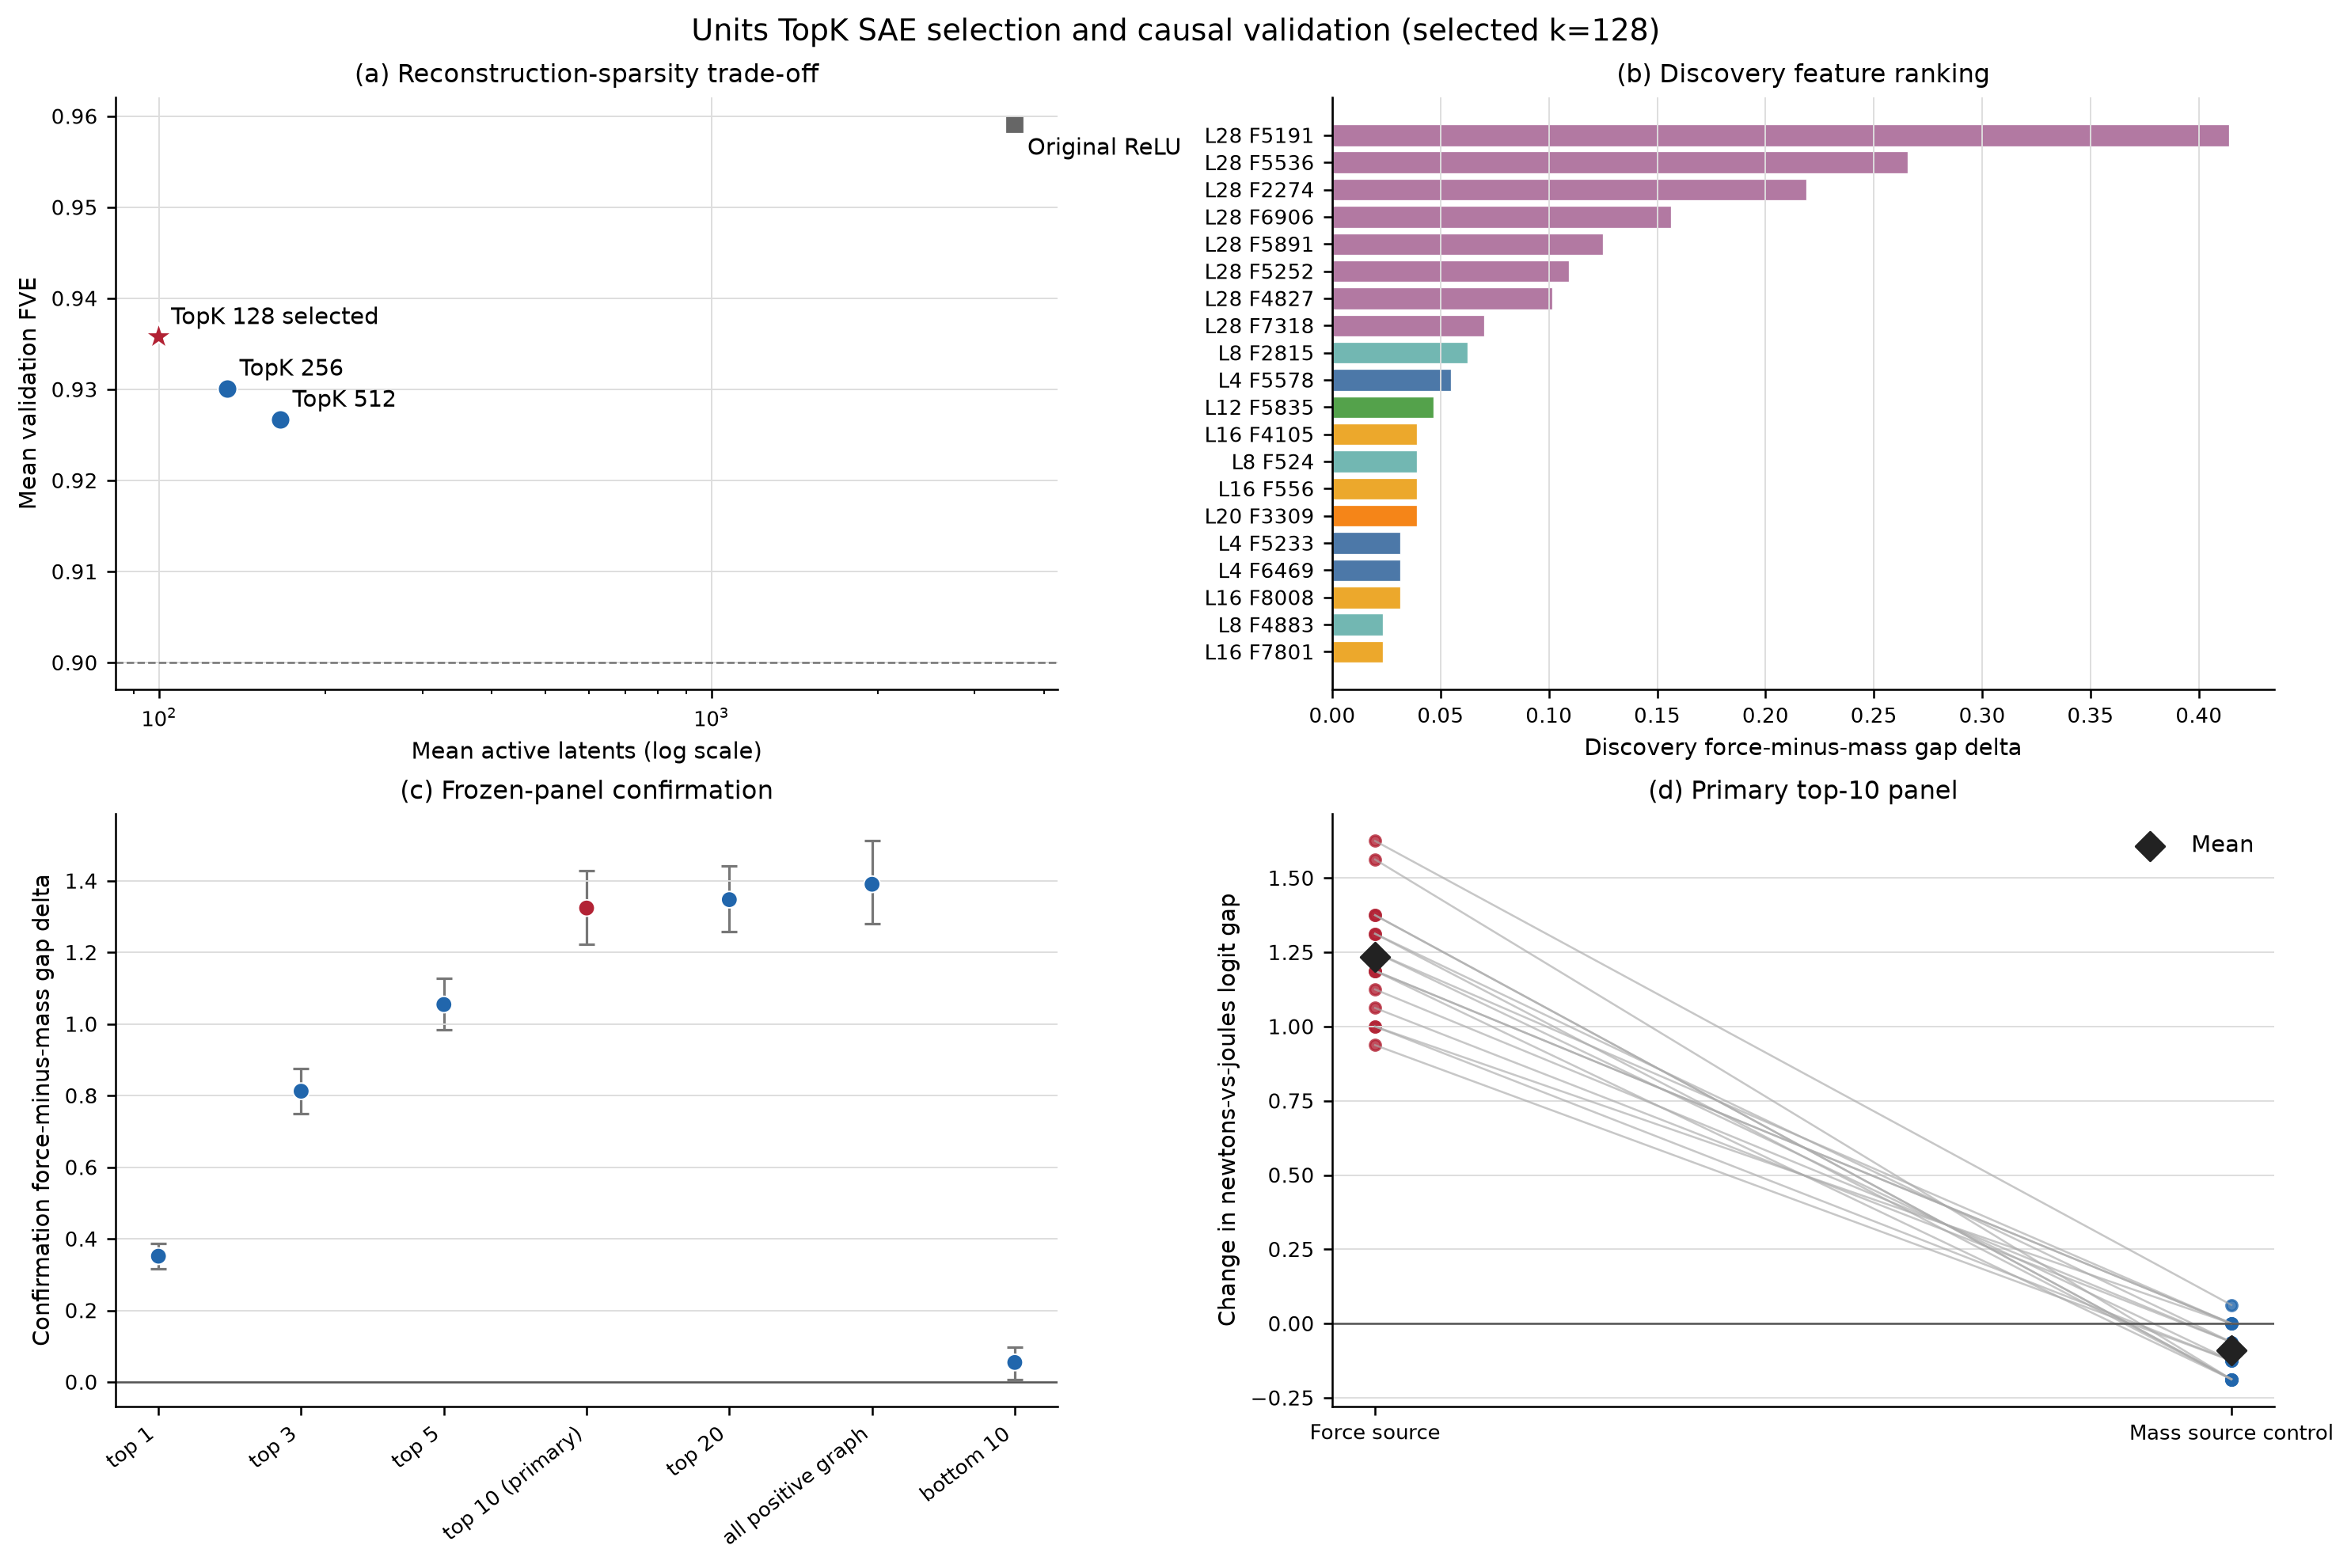

Copied units_topk128_force_graph.md
Copied units_topk512_diagnostics.csv
Copied units_topk128_feature_screen.json
Copied units_topk128_diagnostics.csv
Copied units_topk128_heldout_last.json
Copied units_topk256_diagnostics.json
Copied units_topk_selection.json
Copied units_topk512_diagnostics.json
Copied units_topk128_diagnostics.json
Copied units_topk128_force_graph.json
Copied units_topk128_force_graph.html
Copied units_topk256_diagnostics.csv
Copied figures/fig_units_topk_selection_confirmation.pdf
Copied figures/fig_units_topk_selection_confirmation.png
Units TopK follow-up complete.
Selected k: 128
Drive outputs: /content/drive/MyDrive/mphil-project/outputs/topk_units_retrain


In [10]:
plot_command = [
    sys.executable, '-m', 'src.plot_topk_units',
    '--candidate-diagnostics', *map(str, diagnostic_csvs),
    '--selection', str(selection_path),
    '--screen', str(local_screen_path),
    '--output-dir', str(FIGURE_OUTPUT),
]
original_diagnostics = Path('outputs/final_sae_diagnostics_units.csv')
if original_diagnostics.exists():
    plot_command.extend(['--original-diagnostics', str(original_diagnostics)])
run_cmd(plot_command)

from IPython.display import Image, display
display(Image(filename=str(FIGURE_OUTPUT / 'fig_units_topk_selection_confirmation.png')))

for source in LOCAL_OUTPUT.rglob('*'):
    if source.is_file():
        destination = DRIVE_OUTPUT / source.relative_to(LOCAL_OUTPUT)
        destination.parent.mkdir(parents=True, exist_ok=True)
        shutil.copy2(source, destination)
        print('Copied', source.relative_to(LOCAL_OUTPUT))

print('Units TopK follow-up complete.')
print('Selected k:', SELECTED_K)
print('Drive outputs:', DRIVE_OUTPUT)

## Interpretation gate

- A positive primary result requires both the force-source effect and the force-minus-mass specificity effect to have bootstrap 95% intervals wholly above zero on the untouched confirmation contexts.
- If the primary rule succeeds and matched random panels do not reproduce it, report a compact, final-position force-selective feature panel.
- If the primary rule fails, do not select a secondary panel or another `k`. Report the position-consistent ReLU result and the failed TopK compactness test, then stop experimentation.